In [ ]:
# CELL 1 - RUN THIS FIRST - TOTAL SILENCE GUARANTEED
import os
import warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

# Kill TensorFlow warnings completely
import tensorflow as tf
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

# Suppress protobuf errors (the GetPrototype ones)
from tensorflow.python.util import deprecation
deprecation._PRINT_DEPRECATION_WARNINGS = False

# General Python warnings
warnings.filterwarnings("ignore")
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)

# NOW import everything else safely
import torch
import pandas as pd
import numpy as np
from tqdm import tqdm
# ... rest of your imports

In [ ]:
import pandas as pd

# Load the dataset
input_path = '/kaggle/input/nlp-cp-sl-dataset/test.csv'
df = pd.read_csv(input_path, dtype={'ID': str})   # keep ID as string to avoid any issues

print(f"Original shape: {df.shape}")
print("Columns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

# =============================================
# 1. Clean & standardize the Label column
# =============================================
print("\nCleaning Label column...")

# Convert everything to string first, strip spaces, lower case
df['Label'] = df['Label'].fillna('').astype(str).str.strip().str.lower()

# Map all possible sarcasm labels to 1, non-sarcasm to 0
label_mapping = {
    'yes': 1, 'sarcastic': 1, 'sarcasm': 1, '1': 1, 'true': 1, 't': 1,
    'no': 0, 'not_sarcastic': 0, 'non_sarcastic': 0, '0': 0, 'false': 0, 'f': 0
}

df['Label'] = df['Label'].map(lambda x: label_mapping.get(x, 0))  # default to 0 if unknown

print("Label distribution after cleaning:")
print(df['Label'].value_counts())

# =============================================
# 2. Sort by ID (natural order)
# =============================================
print("\nSorting by ID...")
df['ID'] = pd.to_numeric(df['ID'], errors='coerce')   # convert to number if possible
df = df.sort_values(by='ID').dropna(subset=['ID']).reset_index(drop=True)

# =============================================
# 3. Shuffle properly (most important!)
# =============================================
print("Shuffling the dataset...")
df_shuffled = df.sample(frac=1.0, random_state=42).reset_index(drop=True)

# =============================================
# 4. Final stats
# =============================================
sarcastic_count = df_shuffled['Label'].sum()
total_count = len(df_shuffled)

print("\n" + "="*50)
print("FINAL CLEAN DATASET READY")
print("="*50)
print(f"Total rows       : {total_count}")
print(f"Sarcastic (1)    : {sarcastic_count}")
print(f"Non-sarcastic (0): {total_count - sarcastic_count}")
print(f"Balance          : {sarcastic_count/total_count:.2%} sarcastic")
print("="*50)

# =============================================
# 5. Save the clean version
# =============================================
output_path = '/kaggle/working/test_clean_shuffled.csv'
df_shuffled.to_csv(output_path, index=False)

print(f"\nClean dataset saved to:")
print(output_path)
print("\nUse this path in your training code:")
print('dataset_path = "/kaggle/working/test_clean_shuffled.csv"')

# Show first few rows of final dataset
print("\nFirst 10 rows of final dataset:")
print(df_shuffled.head(10)[['ID', 'Tweet', 'Label']])

2025-11-20 05:42:49.466288: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763617369.488717     175 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763617369.495525     175 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

Val   loss 0.0581 accuracy 0.9872

Epoch 5/5
----------


Training   : 100%|███████████████████████| 569/569 [04:14<00:00,  2.23it/s, loss=0.0001, acc=0.9977]


Train loss 0.0082 accuracy 0.9977


Evaluating : 100%|███████████████████████| 143/143 [00:17<00:00,  8.16it/s, loss=0.0000, acc=0.9864]


Val   loss 0.0775 accuracy 0.9864

Generating Evaluation Metrics...
                    precision    recall  f1-score   support

NO (Non-Sarcastic)       0.99      0.98      0.98       981
   YES (Sarcastic)       0.99      0.99      0.99      1293

          accuracy                           0.99      2274
         macro avg       0.99      0.99      0.99      2274
      weighted avg       0.99      0.99      0.99      2274

Final Accuracy: 98.64%


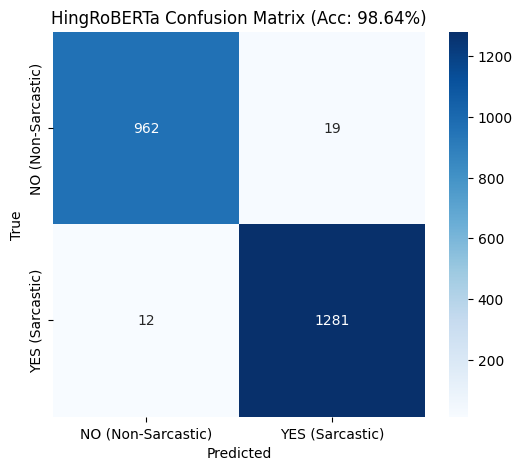

Saving model to /kaggle/working/...
Model saved successfully! You can load it later using AutoModelForSequenceClassification.from_pretrained('./sarcasm_model_saved')


In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import re

# ==========================================
# 1. CONFIGURATION
# ==========================================
dataset_path = '/kaggle/working/unique_tweets_clean_shuffled.csv'

# SWITCHING TO HING-ROBERTA
# This model is optimized for Hindi-English Code-Mixed tweets
MODEL_NAME = 'l3cube-pune/hing-roberta'

MAX_LEN = 128
BATCH_SIZE = 16 
EPOCHS = 5
LEARNING_RATE = 2e-5 # RoBERTa likes small learning rates (1e-5 to 3e-5)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"Loading Model: {MODEL_NAME}")

# ==========================================
# 2. DATA LOADING
# ==========================================
try:
    df = pd.read_csv(dataset_path, encoding='utf-8', on_bad_lines='skip')
except UnicodeDecodeError:
    df = pd.read_csv(dataset_path, encoding='latin-1', on_bad_lines='skip')

# Encode Labels
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['Label'])

# Load RoBERTa Tokenizer (AutoTokenizer handles the specific config for RoBERTa)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class SarcasmDataset(Dataset):
    def __init__(self, tweets, labels, tokenizer, max_len):
        self.tweets = tweets
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
  
    def __len__(self):
        return len(self.tweets)
  
    def __getitem__(self, item):
        tweet = str(self.tweets[item])
        label = self.labels[item]
        
        encoding = self.tokenizer.encode_plus(
            tweet,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        
        return {
            'tweet_text': tweet,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Split Data
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

def create_data_loader(df, tokenizer, max_len, batch_size):
    ds = SarcasmDataset(
        tweets=df['Tweet'].to_numpy(),
        labels=df['label_enc'].to_numpy(),
        tokenizer=tokenizer,
        max_len=max_len
    )
    return DataLoader(ds, batch_size=batch_size, num_workers=0)

train_data_loader = create_data_loader(df_train, tokenizer, MAX_LEN, BATCH_SIZE)
test_data_loader = create_data_loader(df_test, tokenizer, MAX_LEN, BATCH_SIZE)

# ==========================================
# 3. MODEL SETUP
# ==========================================
print("Downloading HingRoBERTa weights...")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)
model = model.to(device)

# Optimizer & Scheduler
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
total_steps = len(train_data_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

# ==========================================
# 4. TRAINING LOOP
# ==========================================


def train_epoch(model, data_loader, optimizer, device, scheduler):
    model.train()
    total_loss = 0
    correct_preds = 0
    total = 0

    # ← THIS LINE FIXES EVERYTHING
    pbar = tqdm(total=len(data_loader), desc=f"Training   ", leave=True, ncols=100, position=0)

    for step, batch in enumerate(data_loader, 1):  # start from 1
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        logits = outputs.logits

        _, preds = torch.max(logits, dim=1)
        correct_preds += torch.sum(preds == labels)
        total += labels.size(0)
        total_loss += loss.item()

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        # Update the SINGLE bar
        pbar.update(1)
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{correct_preds.double()/total:.4f}'
        })

    pbar.close()
    return correct_preds.double() / total, total_loss / len(data_loader)


def eval_model(model, data_loader, device):
    model.eval()
    total_loss = 0
    correct_preds = 0
    total = 0

    pbar = tqdm(total=len(data_loader), desc=f"Evaluating ", leave=True, ncols=100, position=0)

    with torch.no_grad():
        for step, batch in enumerate(data_loader, 1):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            logits = outputs.logits
            _, preds = torch.max(logits, dim=1)

            correct_preds += torch.sum(preds == labels)
            total += labels.size(0)
            total_loss += loss.item()

            pbar.update(1)
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{correct_preds.double()/total:.4f}'
            })

    pbar.close()
    return correct_preds.double() / total, total_loss / len(data_loader)

print("Starting Training...")

for epoch in range(EPOCHS):
    print(f'Epoch {epoch + 1}/{EPOCHS}')
    print('-' * 10)
    
    train_acc, train_loss = train_epoch(model, train_data_loader, optimizer, device, scheduler)
    print(f'Train loss {train_loss:.4f} accuracy {train_acc:.4f}')
    
    val_acc, val_loss = eval_model(model, test_data_loader, device)
    print(f'Val   loss {val_loss:.4f} accuracy {val_acc:.4f}')
    print()

# ==========================================
# 5. FINAL REPORT
# ==========================================
print("Generating Evaluation Metrics...")
model.eval()
y_pred_list = []
y_true_list = []

with torch.no_grad():
    for d in test_data_loader:
        input_ids = d["input_ids"].to(device)
        attention_mask = d["attention_mask"].to(device)
        targets = d["labels"].to(device)
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        _, preds = torch.max(outputs.logits, dim=1)
        
        y_pred_list.extend(preds.cpu().tolist())
        y_true_list.extend(targets.cpu().tolist())

target_names = ['NO (Non-Sarcastic)', 'YES (Sarcastic)']
print(classification_report(y_true_list, y_pred_list, target_names=target_names))
acc = accuracy_score(y_true_list, y_pred_list)
print(f"Final Accuracy: {acc*100:.2f}%")

cm = confusion_matrix(y_true_list, y_pred_list)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'HingRoBERTa Confusion Matrix (Acc: {acc*100:.2f}%)')
plt.show()

# ==========================================
# 6. SAVE THE MODEL
# ==========================================
import os

output_dir = '/kaggle/working/'

# Create directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

print(f"Saving model to {output_dir}...")

# Save the model and the tokenizer
model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)

print("Model saved successfully! You can load it later using AutoModelForSequenceClassification.from_pretrained('./sarcasm_model_saved')")

Using device: cuda
Loading Model: l3cube-pune/hing-mbert


tokenizer_config.json:   0%|          | 0.00/327 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Val   loss 0.0645 accuracy 0.9881

Epoch 5/5
----------


Training   : 100%|███████████████████████| 569/569 [03:52<00:00,  2.44it/s, loss=0.0001, acc=0.9976]


Train loss 0.0080 accuracy 0.9976


Evaluating : 100%|███████████████████████| 143/143 [00:19<00:00,  7.16it/s, loss=0.0000, acc=0.9868]


Val   loss 0.0686 accuracy 0.9868

Generating Evaluation Metrics...
                    precision    recall  f1-score   support

NO (Non-Sarcastic)       0.99      0.98      0.98       981
   YES (Sarcastic)       0.99      0.99      0.99      1293

          accuracy                           0.99      2274
         macro avg       0.99      0.99      0.99      2274
      weighted avg       0.99      0.99      0.99      2274

Final Accuracy: 98.68%


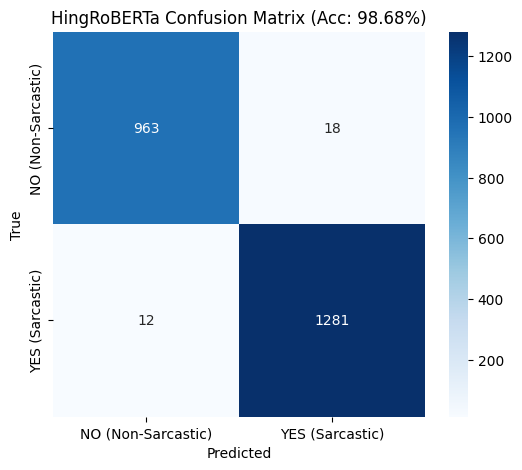

Saving model to /kaggle/working/...
Model saved successfully! You can load it later using AutoModelForSequenceClassification.from_pretrained('./sarcasm_model_saved')


In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import re

# ==========================================
# 1. CONFIGURATION
# ==========================================
dataset_path = '/kaggle/working/unique_tweets_clean_shuffled.csv'

# SWITCHING TO HING-ROBERTA
# This model is optimized for Hindi-English Code-Mixed tweets
MODEL_NAME = 'l3cube-pune/hing-mbert'

MAX_LEN = 128
BATCH_SIZE = 16 
EPOCHS = 5
LEARNING_RATE = 2e-5 # RoBERTa likes small learning rates (1e-5 to 3e-5)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"Loading Model: {MODEL_NAME}")

# ==========================================
# 2. DATA LOADING
# ==========================================
try:
    df = pd.read_csv(dataset_path, encoding='utf-8', on_bad_lines='skip')
except UnicodeDecodeError:
    df = pd.read_csv(dataset_path, encoding='latin-1', on_bad_lines='skip')

# Encode Labels
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['Label'])

# Load RoBERTa Tokenizer (AutoTokenizer handles the specific config for RoBERTa)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class SarcasmDataset(Dataset):
    def __init__(self, tweets, labels, tokenizer, max_len):
        self.tweets = tweets
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
  
    def __len__(self):
        return len(self.tweets)
  
    def __getitem__(self, item):
        tweet = str(self.tweets[item])
        label = self.labels[item]
        
        encoding = self.tokenizer.encode_plus(
            tweet,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        
        return {
            'tweet_text': tweet,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Split Data
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

def create_data_loader(df, tokenizer, max_len, batch_size):
    ds = SarcasmDataset(
        tweets=df['Tweet'].to_numpy(),
        labels=df['label_enc'].to_numpy(),
        tokenizer=tokenizer,
        max_len=max_len
    )
    return DataLoader(ds, batch_size=batch_size, num_workers=0)

train_data_loader = create_data_loader(df_train, tokenizer, MAX_LEN, BATCH_SIZE)
test_data_loader = create_data_loader(df_test, tokenizer, MAX_LEN, BATCH_SIZE)

# ==========================================
# 3. MODEL SETUP
# ==========================================
print("Downloading HingRoBERTa weights...")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)
model = model.to(device)

# Optimizer & Scheduler
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
total_steps = len(train_data_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

# ==========================================
# 4. TRAINING LOOP
# ==========================================


def train_epoch(model, data_loader, optimizer, device, scheduler):
    model.train()
    total_loss = 0
    correct_preds = 0
    total = 0

    # ← THIS LINE FIXES EVERYTHING
    pbar = tqdm(total=len(data_loader), desc=f"Training   ", leave=True, ncols=100, position=0)

    for step, batch in enumerate(data_loader, 1):  # start from 1
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        logits = outputs.logits

        _, preds = torch.max(logits, dim=1)
        correct_preds += torch.sum(preds == labels)
        total += labels.size(0)
        total_loss += loss.item()

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        # Update the SINGLE bar
        pbar.update(1)
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{correct_preds.double()/total:.4f}'
        })

    pbar.close()
    return correct_preds.double() / total, total_loss / len(data_loader)


def eval_model(model, data_loader, device):
    model.eval()
    total_loss = 0
    correct_preds = 0
    total = 0

    pbar = tqdm(total=len(data_loader), desc=f"Evaluating ", leave=True, ncols=100, position=0)

    with torch.no_grad():
        for step, batch in enumerate(data_loader, 1):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            logits = outputs.logits
            _, preds = torch.max(logits, dim=1)

            correct_preds += torch.sum(preds == labels)
            total += labels.size(0)
            total_loss += loss.item()

            pbar.update(1)
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{correct_preds.double()/total:.4f}'
            })

    pbar.close()
    return correct_preds.double() / total, total_loss / len(data_loader)

print("Starting Training...")

for epoch in range(EPOCHS):
    print(f'Epoch {epoch + 1}/{EPOCHS}')
    print('-' * 10)
    
    train_acc, train_loss = train_epoch(model, train_data_loader, optimizer, device, scheduler)
    print(f'Train loss {train_loss:.4f} accuracy {train_acc:.4f}')
    
    val_acc, val_loss = eval_model(model, test_data_loader, device)
    print(f'Val   loss {val_loss:.4f} accuracy {val_acc:.4f}')
    print()

# ==========================================
# 5. FINAL REPORT
# ==========================================
print("Generating Evaluation Metrics...")
model.eval()
y_pred_list = []
y_true_list = []

with torch.no_grad():
    for d in test_data_loader:
        input_ids = d["input_ids"].to(device)
        attention_mask = d["attention_mask"].to(device)
        targets = d["labels"].to(device)
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        _, preds = torch.max(outputs.logits, dim=1)
        
        y_pred_list.extend(preds.cpu().tolist())
        y_true_list.extend(targets.cpu().tolist())

target_names = ['NO (Non-Sarcastic)', 'YES (Sarcastic)']
print(classification_report(y_true_list, y_pred_list, target_names=target_names))
acc = accuracy_score(y_true_list, y_pred_list)
print(f"Final Accuracy: {acc*100:.2f}%")

cm = confusion_matrix(y_true_list, y_pred_list)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'HingRoBERTa Confusion Matrix (Acc: {acc*100:.2f}%)')
plt.show()

# ==========================================
# 6. SAVE THE MODEL
# ==========================================
import os

output_dir = '/kaggle/working/'

# Create directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

print(f"Saving model to {output_dir}...")

# Save the model and the tokenizer
model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)

print("Model saved successfully! You can load it later using AutoModelForSequenceClassification.from_pretrained('./sarcasm_model_saved')")